In [4]:
import cebra
import sys
sys.path.insert(0,'/hdd/miles/velocity_cfm/dnnlib')
from util import Vanderpol,DoubleCircles,DoubleSDE,Lorenz63,Lorenz96,Rossler,projection,Balls
import torch
import numpy as np
import matplotlib.pyplot as plt

## Generate Data

In [16]:
def create_cebra_timelabels(n,T,dt):

    return [np.arange(0,T-dt/2,dt) for _ in range(n)]

In [29]:
gen = Lorenz63()
dataTrain = gen.generate(n=100,T=1,dt=0.01,sigma=0.5)
dataTest = gen.generate(n=20,T=1,dt=0.01,sigma=0.5)
p = projection(origDim=3,newDim=5,projType='swish',temp=1.5)

projectedTrain,projectedTest = [p.project(traj) for traj in dataTrain], [p.project(traj) for traj in dataTest]
labelsTrain = [(ii +1)*np.ones((len(t),),dtype=np.int16) for ii,t in enumerate(projectedTrain)]
labelsTest = [(ii+1 + labelsTrain[-1])*np.ones((len(t),),dtype=np.int16) for ii,t in enumerate(projectedTest)]

In [30]:
time_labels_train = create_cebra_timelabels(100,1,0.01)
time_labels_test = create_cebra_timelabels(20,1,0.01)

In [38]:
params_grid = dict(
    output_dimension = [3],
    learning_rate = [1e-3,1e-4,1e-4],
    time_offsets = [2,5,10,20,50,100],
    max_iterations = 1000,
    temperature_mode = "auto",
    verbose = False,
    batch_size=256)

datasets = {'dataset1': (np.vstack(projectedTrain),np.hstack(time_labels_train))}

grid_search = cebra.grid_search.GridSearch()
grid_search.fit_models(datasets=datasets, params=params_grid, models_dir="/home/miles/isilon/All_Staff/miles/comparison_models/cebra_comparisons")

In [39]:
df_results = grid_search.get_df_results(models_dir="/home/miles/isilon/All_Staff/miles/comparison_models/cebra_comparisons")
best_model, best_model_name = grid_search.get_best_model(dataset_name="dataset1", models_dir="/home/miles/isilon/All_Staff/miles/comparison_models/cebra_comparisons")

In [40]:
df_results.head()

,learning_rate,time_offsets,loss,dataset_name
0,0.001,2,4.635214,dataset1
1,0.001,5,4.767686,dataset1
2,0.001,10,4.898131,dataset1
3,0.001,20,5.105263,dataset1
4,0.001,50,5.217217,dataset1


In [41]:
embedding = best_model.transform(np.vstack(projectedTest))
print(embedding.shape)

(2000, 3)


In [35]:
def compare_representations(true,embedding,plottype='scatter',plotname='./test_model_comparison.png'):
    
    true = np.vstack(true)
    embedding = np.vstack(embedding)
    
    fig = plt.figure(figsize=(10,10))
    
    if (true.shape[-1] == 1) or (len(true.shape) == 1):
        ax = plt.gca()
        trueCounts, trueBins = np.histogram(true,bins=100,density=True)
        embedCounts,embedBins = np.histogram(embedding,bins=trueBins,density=True)
        
        t = ax.stairs(trueCounts,trueBins,edgecolor='#C9303E') #etruscan red
        e = ax.stairs(embedCounts,embedBins,edgecolor='#B4F0D8') #nile blue
        ax.set_xlabel("Data/embed values")
        ax.set_ylabel("Density")
        

    elif true.shape[-1] == 2:
        ax = plt.gca()
        if plottype == 'scatter':
            t = ax.scatter(true[:,0],true[:,1],color='#C9303E',alpha=0.45) #etruscan red
            e = ax.scatter(embedding[:,0],embedding[:,1],color='#B4F0D8',alpha=0.45) #nile blue
        elif plottype == 'line':
            t = ax.plot(true[:,0],true[:,1],color='#C9303E',alpha=0.45) #etruscan red
            e = ax.plot(embedding[:,0],embedding[:,1],color='#B4F0D8',alpha=0.45) #nile blue

        
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    
    elif true.shape[-1] == 3:
        ax1 = fig.add_subplot(121,projection='3d')
        ax2 = fig.add_subplot(122,projection='3d')
        if plottype == 'scatter':
            t = ax1.scatter(true[:,0],true[:,1],true[:,2],color='#C9303E',alpha=0.45) #etruscan red
            e = ax2.scatter(embedding[:,0],embedding[:,1],embedding[:,2],color='#B4F0D8',alpha=0.45) #nile blue
        elif plottype == 'line':
            t = ax1.plot(true[:,0],true[:,1],true[:,2],color='#C9303E',alpha=0.45) #etruscan red
            e = ax2.plot(embedding[:,0],embedding[:,1],embedding[:,2],color='#B4F0D8',alpha=0.45) #nile blue

        ax1.set_xlabel('x1')
        ax1.set_ylabel('x2')
        ax1.set_zlabel('x3')
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax1.set_zticks([])
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax2.set_xlabel('x1')
        ax2.set_ylabel('x2')
        ax2.set_zlabel('x3')
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax2.set_zticks([])
        #ax2.xaxis._axinfo['juggled'] = (0,0,0)
        #ax2.spines['top'].set_visible(False)
        #ax2.spines['right'].set_visible(False)

    
    leg = plt.legend([t,e],['data','embedding'])
   # print(leg.legendHandles)
    for lh in leg.legend_handles: 
        lh.set_alpha(1)
    
    plt.show()
    plt.close()


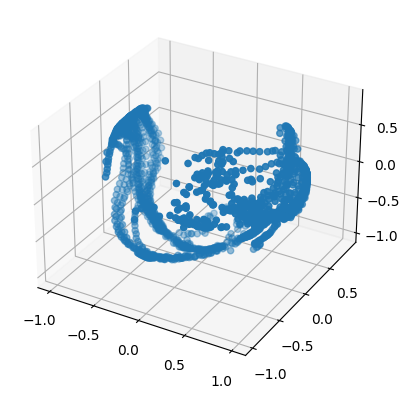

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(embedding[:,0],embedding[:,1],embedding[:,2])
plt.show()
plt.close()

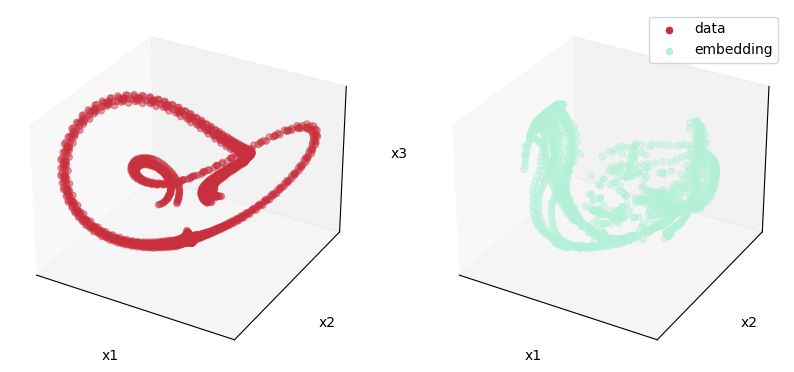

In [43]:
compare_representations(np.vstack(dataTest),embedding)